In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip the folder

import zipfile

zip_path = '/content/drive/MyDrive/fruitsDataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/fruitsDataset')

print("Dataset extracted!")

Dataset extracted!


In [ ]:
# Data Loading

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (64, 64)
batch_size = 32

train_dir = '/content/fruitsDataset/fruitsDataset/Training'
test_dir  = '/content/fruitsDataset/fruitsDataset/Test'

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False   # IMPORTANT
)

num_classes = train_data.num_classes
print("Classes:", num_classes)

Found 34800 images belonging to 3 classes.
Found 12233 images belonging to 3 classes.
Classes: 3


In [ ]:
# ML Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.losses import CategoricalCrossentropy

mlp_model = Sequential([
    Flatten(input_shape=(64, 64, 3)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(32, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

mlp_model.compile(
    optimizer='adam',
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

mlp_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,939 (6.04 MB)

 Trainable params: 1,583,683 (6.04 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# Train ML Model

import time
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# MLP Training
start = time.time()
mlp_history = mlp_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)
mlp_time = time.time() - start


Epoch 1/10
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.7263 - loss: 0.7924 - val_accuracy: 0.7841 - val_loss: 0.7513
Epoch 2/10
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.8630 - loss: 0.5881 - val_accuracy: 0.7184 - val_loss: 0.7806
Epoch 3/10
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.8980 - loss: 0.5265 - val_accuracy: 0.7935 - val_loss: 0.6622
Epoch 4/10
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 37s 34ms/step - accuracy: 0.9191 - loss: 0.4869 - val_accuracy: 0.7642 - val_loss: 0.7541
Epoch 5/10
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.9352 - loss: 0.4572 - val_accuracy: 0.6977 - val_loss: 0.8806


In [ ]:
# CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

cnn_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    # Flatten
    Flatten(),

    # Dense Layer (reduced)
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),

    # Output
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss=CategoricalCrossentropy(label_smoothing=0.15),
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 823,107 (3.14 MB)

 Trainable params: 822,787 (3.14 MB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
# Train CNN Model

import time
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

start = time.time()

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=6,
    callbacks=[early_stop]
)

cnn_time = time.time() - start

Epoch 1/6
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 220s 200ms/step - accuracy: 0.9013 - loss: 0.6418 - val_accuracy: 0.6363 - val_loss: 1.1462
Epoch 2/6
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 215s 197ms/step - accuracy: 0.9840 - loss: 0.4826 - val_accuracy: 0.7996 - val_loss: 1.3609
Epoch 3/6
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 215s 198ms/step - accuracy: 0.9943 - loss: 0.4595 - val_accuracy: 0.7855 - val_loss: 0.9495
Epoch 4/6
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 222s 204ms/step - accuracy: 0.9970 - loss: 0.4487 - val_accuracy: 0.8335 - val_loss: 0.7158
Epoch 5/6
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 232s 213ms/step - accuracy: 0.9984 - loss: 0.4418 - val_accuracy: 0.8707 - val_loss: 0.6762
Epoch 6/6
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 224s 206ms/step - accuracy: 0.9992 - loss: 0.4372 - val_accuracy: 0.8210 - val_loss: 0.6942


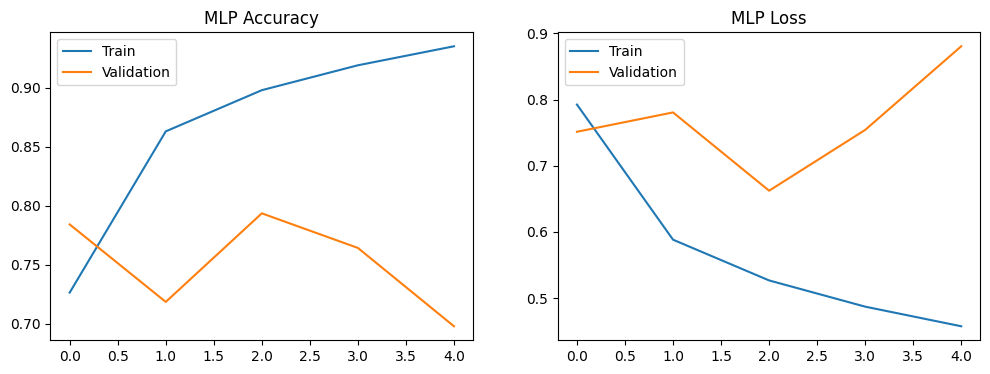

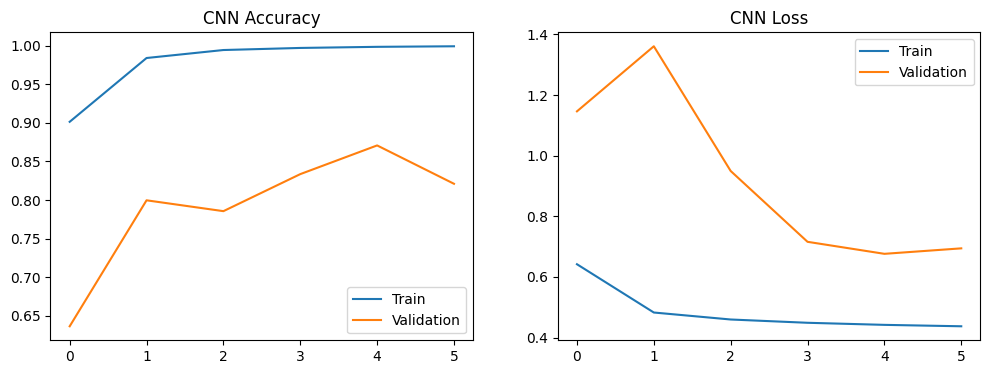

In [ ]:
# Plotting of the curves

import matplotlib.pyplot as plt


def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Plot Training and validation accuracy graph
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.legend(['Train', 'Validation'])

    # Plot Training and validation loss graph
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.legend(['Train', 'Validation'])

    plt.show()

plot_history(mlp_history, "MLP")
plot_history(cnn_history, "CNN")

383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step


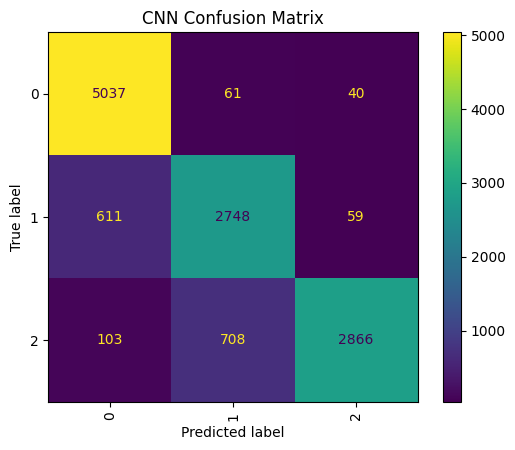

In [ ]:
# Confusion Matrices for MLP Model

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_true = val_data.classes
y_pred_cnn = np.argmax(cnn_model.predict(val_data), axis=1)

cm = confusion_matrix(y_true, y_pred_cnn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.title("CNN Confusion Matrix")
plt.show()

383/383 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step


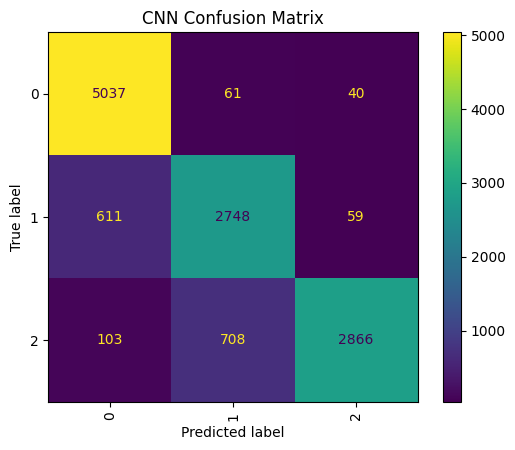

In [ ]:
# Confusion Matrices for CNN Model

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = val_data.classes
y_pred_cnn = np.argmax(cnn_model.predict(val_data), axis=1)

cm = confusion_matrix(y_true, y_pred_cnn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
# Evaluation of both Models

mlp_eval = mlp_model.evaluate(val_data)
cnn_eval = cnn_model.evaluate(val_data)

print(f"MLP Accuracy: {mlp_eval[1]:.4f}, Loss: {mlp_eval[0]:.4f}, Time: {mlp_time:.2f}s")
print(f"CNN Accuracy: {cnn_eval[1]:.4f}, Loss: {cnn_eval[0]:.4f}, Time: {cnn_time:.2f}s")

print("\nMLP Params:", mlp_model.count_params())
print("CNN Params:", cnn_model.count_params())

383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7935 - loss: 0.6622
383/383 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.8707 - loss: 0.6762
MLP Accuracy: 0.7935, Loss: 0.6622, Time: 185.73s
CNN Accuracy: 0.8707, Loss: 0.6762, Time: 1328.88s

MLP Params: 1583939
CNN Params: 823107


Observations/Explanation:

1. The CNN model gives better validation accuracy compared to the MLP model.

2. CNN is able to learn important image features like edges, shapes, and textures, which helps in better classification.

3. MLP converts the image into a flat vector, so it loses spatial information present in images.

4. CNN has more parameters and takes more training time than MLP.

5. CNN shows better generalization because its validation loss is lower and more stable compared to MLP



Final Result:

From the observation, it is clear that CNN performs better than MLP for fruit image classification. CNN can capture spatial features of images, while MLP cannot handle image structure properly. Due to this, CNN achieves higher accuracy and gives more reliable results. Therefore, CNN is more suitable for image classification tasks.